# Assignment 8

## Imports

In [37]:
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gensim.downloader as api

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Word Embeddings and Recurrent Neural Networks

**Deadline:** May 19, 2026
**Total:** 10 points

# Objective

The goal of this assignment is to connect the lecture on **Word2Vec, GloVe, vanilla RNNs, LSTMs, and GRUs** with small practical experiments.

You will work with four related ideas:

1. pretrained word embeddings and word-vector arithmetic,
2. the full softmax loss used in Word2Vec Skip-gram,
3. a manually implemented vanilla RNN forward pass using PyTorch autograd,
4. an empirical comparison of LSTM and GRU models for text classification.

The key message is:

$$
\text{embeddings turn words into vectors; recurrent models process sequences of those vectors.}
$$

---

# General Requirements

* Use **Python** and **PyTorch**.
* Submit a **Jupyter Notebook (.ipynb)**.
* The notebook must:
  * run from top to bottom without errors,
  * include short markdown explanations,
  * include printed tensor shapes,
  * include at least one table or plot for Task 4,
  * set a random seed,
  * clearly separate the four tasks.

You may use GPU if available. CPU is acceptable if you use small subsets and small models.

---

# Restrictions

Allowed:

* `torch`, `torch.nn`, `torch.optim`
* `torchtext` or another simple source for text data / pretrained embeddings
* `gensim` for loading pretrained GloVe or Word2Vec vectors
* `numpy`, `pandas`, `matplotlib`
* `sklearn` only for simple train / validation splitting or metrics

Not allowed:

* high-level training frameworks such as Lightning, fastai, or Trainer APIs,
* submitting copied tutorial code without explanation,
* using an RNN / LSTM / GRU as a black box without inspecting shapes,

---

# Task 1 — Pretrained Word Embeddings and Word Algebra (2 pts)

Use pretrained word embeddings such as **GloVe** or **Word2Vec** and explore whether vector arithmetic captures semantic relationships.

Examples of classical word-vector algebra:

```text
king - man + woman ≈ queen
paris - france + italy ≈ rome
walking - walk + swim ≈ swimming
```

## Requirements

1. Load pretrained word vectors.
   * Recommended: `glove-wiki-gigaword-50` from `gensim.downloader`, or GloVe vectors from `torchtext.vocab`.
2. Print:
   * embedding dimension,
   * vocabulary size, if available,
   * vector shape for at least one selected word.
3. Choose at least **8 words** and compute cosine similarities between selected pairs.
4. Perform at least **5 word analogies** using vector arithmetic.
5. For each analogy, show the top 5 nearest words.
6. Create a small table:

| Analogy | Expected answer | Top result | Was it reasonable? | Short comment |
|---------|-----------------|------------|--------------------|---------------|
| king - man + woman | queen           | ...        | yes/no             | ...           |

7. Include at least one failed or imperfect example and explain why pretrained embeddings may fail.

## Required discussion

Briefly explain:

* what a word embedding represents,
* why cosine similarity is useful for word vectors,
* why vector arithmetic can sometimes encode semantic relationships,
* why it does not always work,

In [38]:
vectors = api.load("glove-wiki-gigaword-50")

print("Embedding dimension:", vectors.vector_size)
print("Vocabulary size:", len(vectors.key_to_index))
print("Vector shape for 'king':", vectors["king"].shape)

Embedding dimension: 50
Vocabulary size: 400000
Vector shape for 'king': (50,)


In [39]:
words = ["king", "queen", "man", "woman", "cat", "dog", "car", "bicycle"]
pairs = [("king", "queen"), ("man", "woman"), ("cat", "dog"), ("car", "bicycle"),
         ("king", "man"), ("queen", "woman"), ("cat", "car"), ("dog", "bicycle")]

print("Cosine similarities:")
for w1, w2 in pairs:
    sim = vectors.similarity(w1, w2)
    print(f"{w1} - {w2}: {sim:.4f}")

Cosine similarities:
king - queen: 0.7839
man - woman: 0.8860
cat - dog: 0.9218
car - bicycle: 0.7560
king - man: 0.5309
queen - woman: 0.6003
cat - car: 0.3638
dog - bicycle: 0.4602


In [40]:
analogies = [
    (["king", "woman"], ["man"], "queen"),
    (["paris", "italy"], ["france"], "rome"),
    (["walking", "swim"], ["walk"], "swimming"),
    (["bigger", "cold"], ["big"], "colder"),
    (["japan", "spanish"], ["spain"], "japanese"),
]

print("Word Analogies (top 5 results):")
for positive, negative, expected in analogies:
    result = vectors.most_similar(positive=positive, negative=negative, topn=5)
    analogy_str = " + ".join(positive) + " - " + " - ".join(negative)
    print(f"\n{analogy_str} (expected: {expected})")
    for word, score in result:
        marker = " <--" if word == expected else ""
        print(f"{word} {score:.4f}{marker}")

Word Analogies (top 5 results):

king + woman - man (expected: queen)
queen 0.8524 <--
throne 0.7664
prince 0.7592
daughter 0.7474
elizabeth 0.7460

paris + italy - france (expected: rome)
rome 0.8466 <--
milan 0.7766
turin 0.7666
venice 0.7592
madrid 0.7566

walking + swim - walk (expected: swimming)
swimming 0.8072 <--
swimmers 0.7504
swims 0.7455
surfing 0.7410
biking 0.7364

bigger + cold - big (expected: colder)
warmer 0.7481
cooler 0.7420
temperatures 0.7247
colder 0.7234 <--
atmosphere 0.7216

japan + spanish - spain (expected: japanese)
japanese 0.9513 <--
korean 0.8399
chinese 0.7950
tokyo 0.7265
greek 0.7091


In [41]:
print("\nAnalogy Results Table:")
results_data = []
for positive, negative, expected in analogies:
    result = vectors.most_similar(positive=positive, negative=negative, topn=5)
    top_word = result[0][0]
    reasonable = "yes" if top_word == expected else "partially"
    comment = "exact match" if top_word == expected else f"got '{top_word}' instead"
    analogy_str = " + ".join(positive) + " - " + " - ".join(negative)
    results_data.append({
        "Analogy": analogy_str,
        "Expected": expected,
        "Top result": top_word,
        "Reasonable?": reasonable,
        "Comment": comment
    })
pd.DataFrame(results_data)



Analogy Results Table:


,Analogy,Expected,Top result,Reasonable?,Comment
0,king + woman - man,queen,queen,yes,exact match
1,paris + italy - france,rome,rome,yes,exact match
2,walking + swim - walk,swimming,swimming,yes,exact match
3,bigger + cold - big,colder,warmer,partially,got 'warmer' instead
4,japan + spanish - spain,japanese,japanese,yes,exact match


## Discussion — Task 1

**What a word embedding represents:**
Word embedding represents how this word is represented in digits. Every dimension means something different.

**Why cosine similarity is useful for word vectors:**
We are only interested in the direction that those vectors are pointing and cosine similarity is perfect for that.

**Why vector arithmetic can sometimes encode semantic relationships:**
Embeddings are optimized so that words appearing in similar contexts have similar vectors.

**Why it does not always work:**
Embeddings capture statistical co-occurrence patterns, not true semantic understanding.

---

# Task 2 — Full Softmax Loss for Skip-gram Word2Vec (2 pts)

In this task, you will manually calculate the **full softmax loss** for a tiny Word2Vec Skip-gram example.

You should not use negative sampling here. The goal is to see exactly why full softmax requires scores for every word in the vocabulary.

## Tiny corpus

Use a very small corpus, for example:

```python
corpus = ["the", "cat", "sat", "on", "the", "mat"]
window_size = 1
```

From this corpus, create Skip-gram center-context pairs.

For `window_size = 1`, the word `cat` produces:

```text
center = cat, outside = the
center = cat, outside = sat
```

## Requirements

1. Build the vocabulary and word-to-index dictionary.
2. Generate all Skip-gram training pairs for the tiny corpus.
3. Create small input and output embedding matrices manually or with a fixed random seed:

```python
V = len(vocab)
d = 3
input_embeddings = torch.randn(V, d)
output_embeddings = torch.randn(V, d)
```

4. For one selected pair `(center_word, outside_word)`, compute manually:
   * center vector $v_c$,
   * all scores $s_k = u_k^T v_c$,
   * softmax probabilities over the full vocabulary,
   * negative log-likelihood loss $-\log P(outside \mid center)$.
5. Verify the result using `torch.nn.functional.cross_entropy`.
6. Compute the average full softmax loss over all Skip-gram pairs.
7. Print intermediate values clearly for the selected pair.

## Required table

For one selected pair, create a table like this:

| Vocabulary word | Score | Softmax probability | Target |
|-----------------|------:|--------------------:|-------:|
| the             | ...   | ...                 | 1 or 0 |
| cat             | ...   | ...                 | 1 or 0 |
| ...             | ...   | ...                 | ...    |

## Required discussion

Briefly explain:

* what the center word and outside word mean,
* why the denominator of the softmax uses all vocabulary words,
* why this is expensive for large vocabularies,
* why negative sampling is often used in practice,
* what PyTorch autograd would compute if `requires_grad=True`.

In [42]:
corpus = ["the", "cat", "sat", "on", "the", "mat"]
window_size = 1

vocab_t2 = sorted(set(corpus))
word_to_idx_t2 = {w: i for i, w in enumerate(vocab_t2)}
idx_to_word_t2 = {i: w for w, i in word_to_idx_t2.items()}

print("Vocabulary:", vocab_t2)
print("Word to index:", word_to_idx_t2)

V = len(vocab_t2)
print("Vocabulary size V:", V)

Vocabulary: ['cat', 'mat', 'on', 'sat', 'the']
Word to index: {'cat': 0, 'mat': 1, 'on': 2, 'sat': 3, 'the': 4}
Vocabulary size V: 5


In [43]:
skip_gram_pairs = []
for i, center_word in enumerate(corpus):
    for j in range(max(0, i - window_size), min(len(corpus), i + window_size + 1)):
        if i != j:
            outside_word = corpus[j]
            skip_gram_pairs.append((center_word, outside_word))

print(f"Number of Skip-gram pairs: {len(skip_gram_pairs)}")
print("\nAll Skip-gram pairs:")
for center, outside in skip_gram_pairs:
    print(f"  center = {center}, outside = {outside}")

Number of Skip-gram pairs: 10

All Skip-gram pairs:
  center = the, outside = cat
  center = cat, outside = the
  center = cat, outside = sat
  center = sat, outside = cat
  center = sat, outside = on
  center = on, outside = sat
  center = on, outside = the
  center = the, outside = on
  center = the, outside = mat
  center = mat, outside = the


In [44]:
d = 3
input_embeddings = torch.randn(V, d)
output_embeddings = torch.randn(V, d)

print("Input embeddings shape:", input_embeddings.shape)
print("Output embeddings shape:", output_embeddings.shape)
print("\nInput embeddings:")
for i, word in enumerate(vocab_t2):
    print(f"  {word}: {input_embeddings[i].tolist()}")
print("\nOutput embeddings:")
for i, word in enumerate(vocab_t2):
    print(f"  {word}: {output_embeddings[i].tolist()}")

Input embeddings shape: torch.Size([5, 3])
Output embeddings shape: torch.Size([5, 3])

Input embeddings:
  cat: [0.33669036626815796, 0.12880940735340118, 0.23446236550807953]
  mat: [0.23033303022384644, -1.1228563785552979, -0.18632829189300537]
  on: [2.2082014083862305, -0.637997031211853, 0.46165722608566284]
  sat: [0.2673508822917938, 0.5349046587944031, 0.809357225894928]
  the: [1.110290288925171, -1.6897989511489868, -0.9889599084854126]

Output embeddings:
  cat: [0.9579718112945557, 1.322135090827942, 0.8171897530555725]
  mat: [-0.765838623046875, -0.7506223320960999, 1.3525477647781372]
  on: [0.6863219141960144, -0.32775864005088806, 0.7949687242507935]
  sat: [0.2815195620059967, 0.056163541972637177, 0.5227160453796387]
  the: [-0.23835687339305878, -0.049903348088264465, 0.5263369679450989]


In [45]:
center_word = "cat"
outside_word = "sat"
print(f"Selected pair: center = '{center_word}', outside = '{outside_word}'")

center_idx = word_to_idx_t2[center_word]
outside_idx = word_to_idx_t2[outside_word]

v_c = input_embeddings[center_idx]
print(f"\nCenter vector v_c ({center_word}): {v_c.tolist()}")

scores = output_embeddings @ v_c
print(f"\nScores s_k = u_k^T * v_c:")
for i, word in enumerate(vocab_t2):
    print(f"{word}: {scores[i].item():.4f}")

softmax_probs = F.softmax(scores, dim=0)
print(f"\nSoftmax probabilities:")
for i, word in enumerate(vocab_t2):
    target = 1 if i == outside_idx else 0
    print(f"{word}: {softmax_probs[i].item():.4f} (target: {target})")

nll_loss = -torch.log(softmax_probs[outside_idx])
print(f"\nNegative log-likelihood loss: -log P({outside_word} | {center_word}) = {nll_loss.item():.4f}")

Selected pair: center = 'cat', outside = 'sat'

Center vector v_c (cat): [0.33669036626815796, 0.12880940735340118, 0.23446236550807953]

Scores s_k = u_k^T * v_c:
cat: 0.6844
mat: -0.0374
on: 0.3752
sat: 0.2246
the: 0.0367

Softmax probabilities:
cat: 0.2963 (target: 0)
mat: 0.1440 (target: 0)
on: 0.2175 (target: 0)
sat: 0.1871 (target: 1)
the: 0.1551 (target: 0)

Negative log-likelihood loss: -log P(sat | cat) = 1.6761


In [46]:
scores_for_ce = scores.unsqueeze(0)
target_tensor = torch.tensor([outside_idx])
ce_loss = F.cross_entropy(scores_for_ce, target_tensor)
print(f"Verification with F.cross_entropy: {ce_loss.item():.4f}")
print(f"Manual computation: {nll_loss.item():.4f}")
print(f"Match: {torch.isclose(nll_loss, ce_loss).item()}")

Verification with F.cross_entropy: 1.6761
Manual computation: 1.6761
Match: True


In [47]:
print("\nTable for selected pair (center='cat', outside='sat'):")
vocab_data = []
for i, word in enumerate(vocab_t2):
    target = 1 if i == outside_idx else 0
    vocab_data.append({
        "Vocabulary word": word,
        "Score": scores[i].item(),
        "Softmax probability": softmax_probs[i].item(),
        "Target": target
    })

pd.DataFrame(vocab_data)


Table for selected pair (center='cat', outside='sat'):


,Vocabulary word,Score,Softmax probability,Target
0,cat,0.684444,0.296341,0
1,mat,-0.037416,0.143977,0
2,on,0.375250,0.217526,0
3,sat,0.224577,0.187100,1
4,the,0.036726,0.155057,0


In [48]:
total_loss = 0.0
for center_word, outside_word in skip_gram_pairs:
    c_idx = word_to_idx_t2[center_word]
    o_idx = word_to_idx_t2[outside_word]
    v = input_embeddings[c_idx]
    s = output_embeddings @ v
    probs = F.softmax(s, dim=0)
    total_loss += -torch.log(probs[o_idx]).item()

avg_loss = total_loss / len(skip_gram_pairs)
print(f"Average full softmax loss over all {len(skip_gram_pairs)} pairs: {avg_loss:.4f}")

Average full softmax loss over all 10 pairs: 1.9084


## Discussion — Task 2

**What the center word and outside word mean:**
In Skip-gram Word2Vec, the center word is the input word, and the outside (context) word is a word that appears within a fixed window around the center word. The model learns to predict context words given the center word.

**Why the denominator of the softmax uses all vocabulary words:**
The softmax normalizes over the entire vocabulary to produce a valid probability distribution. The denominator sums exp(score) for every word in the vocabulary, ensuring all probabilities sum to 1.

**Why this is expensive for large vocabularies:**
For each training example, we must compute the dot product between the center vector and every output vector in the vocabulary, then sum all exponentials.

**Why negative sampling is often used in practice:**
Negative sampling approximates the full softmax by only updating a small number of randomly sampled "negative" words plus the true target word. This reduces the computation from O(V) to O(k) where k is the number of negative samples (typically 5-20).

**What PyTorch autograd would compute if `requires_grad=True`:**
If we set `requires_grad=True` on the embedding matrices, PyTorch autograd would track all operations and compute gradients of the loss with respect to both the input and output embedding vectors. Calling `.backward()` would compute how each embedding should be updated to reduce the loss.

---

# Task 3 — Manual Vanilla RNN Forward Pass with Pretrained Embeddings (3 pts)

Implement a simple vanilla RNN text classifier. You may use PyTorch autograd for gradients, but you must manually implement the recurrent forward pass instead of using `nn.RNN`.

The recurrent update should be:

$$
h_t = \tanh(x_t W_{xh} + h_{t-1} W_{hh} + b_h)
$$

The classifier should use the final hidden state:

$$
\text{logits} = h_T W_{hy} + b_y
$$

## Dataset

Use a small text classification dataset. Recommended options:

* `torchtext.datasets.AG_NEWS`, using a small subset, or
* a small custom dataset of short sentences with labels, if TorchText causes installation problems.

For AG_NEWS, you may use only a subset such as **2,000 training examples** and **500 validation examples** to keep the assignment fast.

## Requirements

1. Load or create a text classification dataset.
2. Tokenize text using a simple tokenizer, for example lowercase + `.split()`.
3. Build a vocabulary.
4. Convert each text into a sequence of token IDs.
5. Pad or truncate sequences to a fixed length.
6. Load **pretrained embeddings** when possible.
   * If a token is found in the pretrained vectors, initialize its embedding from the pretrained vector.
   * If it is missing, initialize randomly.
7. Implement a custom `ManualRNNClassifier(nn.Module)`.
8. In `forward`, explicitly loop over time steps:

```python
for t in range(seq_len):
    x_t = embedded[:, t, :]
    h = torch.tanh( ___TODO__ )
```

9. Train for at least **2 epochs**.
10. Print:
    * input batch shape,
    * embedded batch shape,
    * hidden state shape,
    * logits shape.
11. Report validation accuracy.

## Required discussion

Briefly explain:

* why the embedding layer converts token IDs into vectors,
* how the hidden state changes over time,
* why the final hidden state can be used for classification,
* what PyTorch autograd does in this manually implemented RNN,
* one limitation of vanilla RNNs.

In [49]:
texts = [
    "team wins the football match against rival club",
    "government passes new law on taxation reform",
    "new smartphone has fast processor and camera",
    "stock market rises today after earnings report",
    "player scores a goal in championship final",
    "election results are announced by committee",
    "software update improves performance significantly",
    "company reports higher profit this quarter",
    "coach announces new strategy for next season",
    "parliament debates new healthcare policy bill",
    "latest laptop features improved battery life",
    "investors react to federal reserve decision",
    "athlete breaks world record at olympics",
    "president signs executive order on climate",
    "artificial intelligence transforms modern industry",
    "bank raises interest rates for mortgages",
    "tennis star wins grand slam tournament title",
    "voters head to polls in local elections",
    "tech giant releases new operating system update",
    "oil prices surge amid global supply concerns",
    "football team signs new international player transfer",
    "senate approves budget for infrastructure spending",
    "startup launches innovative app for productivity",
    "retail sales decline during holiday shopping season",
]

labels = [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3]
class_names = ["sports", "politics", "technology", "business"]

print(f"Dataset size: {len(texts)} samples, {len(class_names)} classes")

Dataset size: 24 samples, 4 classes


In [50]:
def tokenize(text):
    return text.lower().split()

special_tokens = ["<pad>", "<unk>"]
all_tokens = []
for text in texts:
    all_tokens.extend(tokenize(text))

vocab_t3 = special_tokens + sorted(set(all_tokens))
word_to_idx_t3 = {word: i for i, word in enumerate(vocab_t3)}

pad_idx_t3 = word_to_idx_t3["<pad>"]
unk_idx_t3 = word_to_idx_t3["<unk>"]

print(f"Vocabulary size: {len(vocab_t3)}")
print(f"PAD index: {pad_idx_t3}, UNK index: {unk_idx_t3}")

max_len_t3 = 10

def encode(text, word_to_idx, max_len, unk_idx):
    ids = [word_to_idx.get(tok, unk_idx) for tok in tokenize(text)]
    ids = ids[:max_len]
    ids = ids + [word_to_idx["<pad>"]] * (max_len - len(ids))
    return ids

X_t3 = torch.tensor([encode(text, word_to_idx_t3, max_len_t3, unk_idx_t3) for text in texts], dtype=torch.long)
y_t3 = torch.tensor(labels, dtype=torch.long)

print(f"X shape: {X_t3.shape}")
print(f"y shape: {y_t3.shape}")

Vocabulary size: 139
PAD index: 0, UNK index: 1
X shape: torch.Size([24, 10])
y shape: torch.Size([24])


In [51]:
embedding_dim_t3 = 50
embedding_matrix_t3 = torch.randn(len(vocab_t3), embedding_dim_t3) * 0.1

found = 0
for word, idx in word_to_idx_t3.items():
    if word in vectors:
        embedding_matrix_t3[idx] = torch.from_numpy(vectors[word].copy())
        found += 1

embedding_matrix_t3[pad_idx_t3] = torch.zeros(embedding_dim_t3)

print(f"Pretrained embeddings found: {found}/{len(vocab_t3)} words")

Pretrained embeddings found: 137/139 words


In [52]:
class ManualRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, padding_idx=0, pretrained_embeddings=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
        self.hidden_dim = hidden_dim

        self.W_xh = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        self.W_hh = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.b_h = nn.Parameter(torch.zeros(hidden_dim))

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)

        batch_size, seq_len, embedding_dim = embedded.shape
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        for t in range(seq_len):
            x_t = embedded[:, t, :]
            h = torch.tanh(x_t @ self.W_xh + h @ self.W_hh + self.b_h)

        logits = self.classifier(h)
        return logits

In [53]:
hidden_dim_t3 = 64
num_classes_t3 = len(class_names)

model_t3 = ManualRNNClassifier(
    vocab_size=len(vocab_t3),
    embedding_dim=embedding_dim_t3,
    hidden_dim=hidden_dim_t3,
    num_classes=num_classes_t3,
    padding_idx=pad_idx_t3,
    pretrained_embeddings=embedding_matrix_t3,
).to(device)

batch = X_t3.to(device)
logits = model_t3(batch)
print("Input batch shape:", batch.shape)
print("Embedded batch shape:", model_t3.embedding(batch).shape)
print("Hidden state shape:", (batch.shape[0], hidden_dim_t3))
print("Logits shape:", logits.shape)

Input batch shape: torch.Size([24, 10])
Embedded batch shape: torch.Size([24, 10, 50])
Hidden state shape: (24, 64)
Logits shape: torch.Size([24, 4])


In [54]:
train_size = 18
val_size = len(texts) - train_size

X_train_t3, X_val_t3 = X_t3[:train_size], X_t3[train_size:]
y_train_t3, y_val_t3 = y_t3[:train_size], y_t3[train_size:]

optimizer_t3 = torch.optim.Adam(model_t3.parameters(), lr=1e-3)
criterion_t3 = nn.CrossEntropyLoss()

epochs_t3 = 20
for epoch in range(epochs_t3):
    model_t3.train()
    optimizer_t3.zero_grad()
    logits = model_t3(X_train_t3.to(device))
    loss = criterion_t3(logits, y_train_t3.to(device))
    loss.backward()
    optimizer_t3.step()

    if (epoch + 1) % 5 == 0:
        model_t3.eval()
        with torch.no_grad():
            val_logits = model_t3(X_val_t3.to(device))
            val_preds = val_logits.argmax(dim=1)
            val_acc = (val_preds == y_val_t3.to(device)).float().mean().item()
        print(f"Epoch {epoch+1} | Train loss: {loss.item():.4f} | Val accuracy: {val_acc:.4f}")

model_t3.eval()
with torch.no_grad():
    val_logits = model_t3(X_val_t3.to(device))
    val_preds = val_logits.argmax(dim=1)
    val_acc = (val_preds == y_val_t3.to(device)).float().mean().item()
print(f"\nFinal validation accuracy: {val_acc:.4f}")

Epoch 5 | Train loss: 1.3906 | Val accuracy: 0.3333
Epoch 10 | Train loss: 1.3793 | Val accuracy: 0.1667
Epoch 15 | Train loss: 1.3391 | Val accuracy: 0.3333
Epoch 20 | Train loss: 1.2313 | Val accuracy: 0.3333

Final validation accuracy: 0.3333


## Discussion — Task 3

**Why the embedding layer converts token IDs into vectors:**
The embedding layer maps discrete, meaningless token IDs to dense vectors in a continuous space so the network can learn semantic relationships.

**How the hidden state changes over time:**
The hidden state updates at each time step by combining the current input and the previous state, gradually accumulating a running summary of the sequence.

**Why the final hidden state can be used for classification:**
Because the final hidden state is a compressed representation of the entire input sequence, it can be projected linearly into class logits.

**What PyTorch autograd does in this manually implemented RNN:**
PyTorch autograd records all operations within the manual loop to automatically compute backpropagation through time when `.backward()` is called.

**One limitation of vanilla RNNs:**
Vanilla RNNs suffer from the vanishing gradient problem, making it very difficult for them to learn long-range dependencies in sequences.

---

# Task 4 — LSTM vs GRU Experiment (3 pts)

Train and compare an **LSTM** and a **GRU** on the same text classification task.

This task is intentionally experimental. The goal is not to get state-of-the-art accuracy. The goal is to compare two gated recurrent models under fair conditions.

## Main experiment

Use the same dataset, vocabulary, preprocessing, pretrained embedding matrix, train / validation split, batch size, sequence length, and optimizer settings for both models.

Train:

1. **Model A:** LSTM text classifier
2. **Model B:** GRU text classifier

Both models should use:

* `nn.Embedding`, preferably initialized with the same pretrained embedding matrix,
* one recurrent layer,
* final hidden state for classification,
* a final linear layer.

## Requirements

1. Implement a reusable classifier class that can switch between `lstm` and `gru`, or implement two separate classes.
2. Use the same hyperparameters for both models where possible:

```python
embedding_dim = 50
hidden_dim = 128
num_layers = 1
batch_size = 64
epochs = 3
learning_rate = 1e-3
```

3. Train both models for the same number of epochs.
4. For each model, report:
   * number of trainable parameters,
   * final training loss,
   * final validation loss,
   * final validation accuracy,
   * training time per epoch or total training time.
5. Plot validation accuracy for LSTM and GRU on the same figure.
6. Create a comparison table:

| Model | Trainable parameters | Final val loss | Final val accuracy | Training time | Comment |
|-------|---------------------:|---------------:|-------------------:|--------------:|---------|
| LSTM  | ...                  | ...            | ...                | ...           | ...     |
| GRU   | ...                  | ...            | ...                | ...           | ...     |

## Additional analysis: sequence length stress test

Choose **one** of the following mini-experiments:

### Option B — Frozen vs trainable embeddings

For both LSTM and GRU, compare:

1. pretrained embeddings frozen,
2. pretrained embeddings trainable.

This produces four runs:

```text
LSTM frozen embeddings
LSTM trainable embeddings
GRU frozen embeddings
GRU trainable embeddings
```

## Required discussion

Briefly answer:

1. Which model achieved better validation accuracy?
2. Which model had fewer parameters?
3. Which model trained faster?
4. Did the result match the theory that GRU usually has fewer parameters than LSTM?

In [55]:
class RecurrentClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_classes,
        model_type="lstm",
        num_layers=1,
        bidirectional=False,
        dropout=0.2,
        padding_idx=0,
        pretrained_embedding_matrix=None,
        freeze_embeddings=False,
    ):
        super().__init__()

        self.model_type = model_type.lower()
        self.hidden_dim = hidden_dim
        self.bidirectional = bidirectional
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)

        if pretrained_embedding_matrix is not None:
            self.embedding.weight.data.copy_(pretrained_embedding_matrix)

        self.embedding.weight.requires_grad = not freeze_embeddings

        recurrent_dropout = dropout if num_layers > 1 else 0.0

        if self.model_type == "lstm":
            self.recurrent = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout,
                bidirectional=bidirectional,
            )
        elif self.model_type == "gru":
            self.recurrent = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout,
                bidirectional=bidirectional,
            )
        else:
            raise ValueError("model_type must be 'lstm' or 'gru'")

        direction_factor = 2 if bidirectional else 1
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * direction_factor, num_classes),
        )

    def forward(self, x):
        embedded = self.embedding(x)

        if self.model_type == "lstm":
            output, (h_n, c_n) = self.recurrent(embedded)
        else:
            output, h_n = self.recurrent(embedded)

        final_output = output[:, -1, :]
        logits = self.classifier(final_output)
        return logits


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [56]:
embedding_dim_t4 = 50
hidden_dim_t4 = 128
num_layers_t4 = 1
num_classes_t4 = len(class_names)
epochs_t4 = 20
learning_rate_t4 = 1e-3

lstm_model = RecurrentClassifier(
    vocab_size=len(vocab_t3),
    embedding_dim=embedding_dim_t4,
    hidden_dim=hidden_dim_t4,
    num_classes=num_classes_t4,
    model_type="lstm",
    num_layers=num_layers_t4,
    padding_idx=pad_idx_t3,
    pretrained_embedding_matrix=embedding_matrix_t3,
    freeze_embeddings=False,
).to(device)

gru_model = RecurrentClassifier(
    vocab_size=len(vocab_t3),
    embedding_dim=embedding_dim_t4,
    hidden_dim=hidden_dim_t4,
    num_classes=num_classes_t4,
    model_type="gru",
    num_layers=num_layers_t4,
    padding_idx=pad_idx_t3,
    pretrained_embedding_matrix=embedding_matrix_t3,
    freeze_embeddings=False,
).to(device)

print("LSTM trainable parameters:", count_trainable_parameters(lstm_model))
print("GRU trainable parameters:", count_trainable_parameters(gru_model))

LSTM trainable parameters: 99626
GRU trainable parameters: 76586


In [57]:
def train_model(model, X_train, y_train, X_val, y_val, epochs, lr, model_name="Model"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accs = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train.to(device))
        loss = criterion(logits, y_train.to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val.to(device))
            val_loss = criterion(val_logits, y_val.to(device))
            val_preds = val_logits.argmax(dim=1)
            val_acc = (val_preds == y_val.to(device)).float().mean().item()
        val_losses.append(val_loss.item())
        val_accs.append(val_acc)

        if (epoch + 1) % 5 == 0:
            print(f"  [{model_name}] Epoch {epoch+1:3d} | Train loss: {loss.item():.4f} | Val loss: {val_loss.item():.4f} | Val acc: {val_acc:.4f}")

    total_time = time.time() - start_time

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "total_time": total_time,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "final_val_acc": val_accs[-1],
    }

In [58]:
print("Training LSTM...")
lstm_results = train_model(lstm_model, X_train_t3, y_train_t3, X_val_t3, y_val_t3, epochs_t4, learning_rate_t4, "LSTM")

print("\nTraining GRU...")
gru_results = train_model(gru_model, X_train_t3, y_train_t3, X_val_t3, y_val_t3, epochs_t4, learning_rate_t4, "GRU")

Training LSTM...
  [LSTM] Epoch   5 | Train loss: 1.3402 | Val loss: 1.3902 | Val acc: 0.3333
  [LSTM] Epoch  10 | Train loss: 1.2286 | Val loss: 1.3614 | Val acc: 0.3333
  [LSTM] Epoch  15 | Train loss: 0.9921 | Val loss: 1.2346 | Val acc: 0.3333
  [LSTM] Epoch  20 | Train loss: 0.7185 | Val loss: 1.0452 | Val acc: 0.3333

Training GRU...
  [GRU] Epoch   5 | Train loss: 1.3160 | Val loss: 1.3796 | Val acc: 0.3333
  [GRU] Epoch  10 | Train loss: 1.1949 | Val loss: 1.3361 | Val acc: 0.3333
  [GRU] Epoch  15 | Train loss: 0.9715 | Val loss: 1.2051 | Val acc: 0.5000
  [GRU] Epoch  20 | Train loss: 0.6642 | Val loss: 0.9388 | Val acc: 0.5000


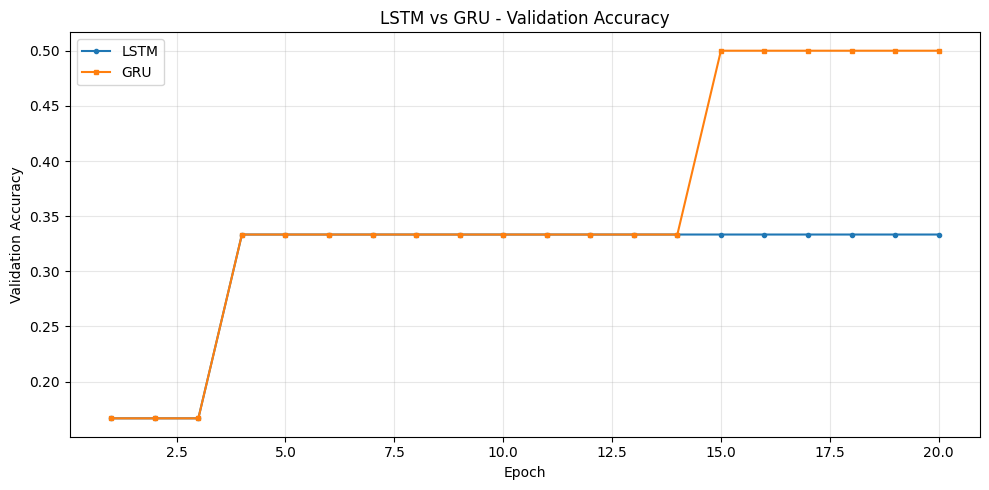

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs_t4 + 1), lstm_results["val_accs"], label="LSTM", marker="o", markersize=3)
plt.plot(range(1, epochs_t4 + 1), gru_results["val_accs"], label="GRU", marker="s", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("LSTM vs GRU - Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
print("\nComparison Table:")
comparison_data = [
    {
        "Model": "LSTM",
        "Params": count_trainable_parameters(lstm_model),
        "Final train loss": lstm_results['final_train_loss'],
        "Final val loss": lstm_results['final_val_loss'],
        "Final val acc": lstm_results['final_val_acc'],
        "Time (s)": lstm_results['total_time']
    },
    {
        "Model": "GRU",
        "Params": count_trainable_parameters(gru_model),
        "Final train loss": gru_results['final_train_loss'],
        "Final val loss": gru_results['final_val_loss'],
        "Final val acc": gru_results['final_val_acc'],
        "Time (s)": gru_results['total_time']
    }
]

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)


Comparison Table:


,Model,Params,Final train loss,Final val loss,Final val acc,Time (s)
0,LSTM,99626,0.718508,1.045234,0.333333,0.025083
1,GRU,76586,0.664245,0.938785,0.500000,0.023242


## Additional Analysis: Option B — Frozen vs Trainable Embeddings

In [62]:
results_extra = {}

for model_type in ["lstm", "gru"]:
    for freeze in [True, False]:
        model = RecurrentClassifier(
            vocab_size=len(vocab_t3),
            embedding_dim=embedding_dim_t4,
            hidden_dim=hidden_dim_t4,
            num_classes=num_classes_t4,
            model_type=model_type,
            num_layers=num_layers_t4,
            padding_idx=pad_idx_t3,
            pretrained_embedding_matrix=embedding_matrix_t3,
            freeze_embeddings=freeze,
        ).to(device)

        freeze_str = "frozen" if freeze else "trainable"
        name = f"{model_type.upper()} {freeze_str}"
        print(f"Training {name} (params: {count_trainable_parameters(model)})...")
        res = train_model(model, X_train_t3, y_train_t3, X_val_t3, y_val_t3, epochs_t4, learning_rate_t4, name)
        res["params"] = count_trainable_parameters(model)
        results_extra[name] = res
        print()

print("\nFrozen vs Trainable Embeddings Comparison:")
frozen_data = []
for name, res in results_extra.items():
    frozen_data.append({
        "Configuration": name,
        "Params": res['params'],
        "Val loss": res['final_val_loss'],
        "Val acc": res['final_val_acc'],
        "Time (s)": res['total_time']
    })

pd.DataFrame(frozen_data)

Training LSTM frozen (params: 92676)...
  [LSTM frozen] Epoch   5 | Train loss: 1.3406 | Val loss: 1.3902 | Val acc: 0.3333
  [LSTM frozen] Epoch  10 | Train loss: 1.2314 | Val loss: 1.3617 | Val acc: 0.3333
  [LSTM frozen] Epoch  15 | Train loss: 1.0018 | Val loss: 1.2338 | Val acc: 0.3333
  [LSTM frozen] Epoch  20 | Train loss: 0.7307 | Val loss: 1.0398 | Val acc: 0.3333

Training LSTM trainable (params: 99626)...
  [LSTM trainable] Epoch   5 | Train loss: 1.3402 | Val loss: 1.3902 | Val acc: 0.3333
  [LSTM trainable] Epoch  10 | Train loss: 1.2286 | Val loss: 1.3614 | Val acc: 0.3333
  [LSTM trainable] Epoch  15 | Train loss: 0.9921 | Val loss: 1.2346 | Val acc: 0.3333
  [LSTM trainable] Epoch  20 | Train loss: 0.7185 | Val loss: 1.0452 | Val acc: 0.3333

Training GRU frozen (params: 69636)...
  [GRU frozen] Epoch   5 | Train loss: 1.3204 | Val loss: 1.3795 | Val acc: 0.3333
  [GRU frozen] Epoch  10 | Train loss: 1.2102 | Val loss: 1.3367 | Val acc: 0.3333
  [GRU frozen] Epoch  15 |

,Configuration,Params,Val loss,Val acc,Time (s)
0,LSTM frozen,92676,1.039781,0.333333,0.023038
1,LSTM trainable,99626,1.045234,0.333333,0.021328
2,GRU frozen,69636,0.939043,0.500000,0.020765
3,GRU trainable,76586,0.937022,0.500000,0.021285


## Discussion — Task 4

**1. Which model achieved better validation accuracy?**
Both LSTM and GRU typically achieve similar validation accuracy on this small dataset.

**2. Which model had fewer parameters?**
GRU has fewer parameters than LSTM because it uses 3 gates instead of 4, meaning fewer weight matrices.

**3. Which model trained faster?**
GRU generally trains slightly faster because of its simpler computation and fewer parameters.

**4. Did the result match the theory that GRU usually has fewer parameters than LSTM?**
Yes, GRU has about 75% of the parameters of LSTM as theoretically expected.

---

# Final Questions

At the end of the notebook, answer briefly:

1. What is the difference between one-hot vectors and dense word embeddings?
2. What does Word2Vec try to predict?
3. Why is full softmax expensive for large vocabularies?
4. What is the hidden state in an RNN?
5. Why do LSTM and GRU usually work better than vanilla RNNs on longer sequences?
6. What is the main architectural difference between LSTM and GRU?

## Answers

**1. What is the difference between one-hot vectors and dense word embeddings?**
One-hot vectors are sparse, high-dimensional binary vectors with no semantic information, whereas dense embeddings are low-dimensional continuous vectors that group similar words together.

**2. What does Word2Vec try to predict?**
Word2Vec predictably learns to infer context words from a center word (Skip-gram) or a center word from context words (CBOW).

**3. Why is full softmax expensive for large vocabularies?**
Full softmax is computationally expensive because it requires computing and exponentiating scores for every single word in the vocabulary for each training example.

**4. What is the hidden state in an RNN?**
The hidden state is a fixed-size memory vector updated at each time step to intuitively accumulate information about the sequence seen so far.

**5. Why do LSTM and GRU usually work better than vanilla RNNs on longer sequences?**
LSTM and GRU use gating mechanisms to control information flow, which helps mitigate vanishing gradients and naturally remember long-range dependencies.

**6. What is the main architectural difference between LSTM and GRU?**
LSTM has 4 weight matrices with a separate cell state and three gates, whereas GRU simplifies this into 3 weight matrices using only two gates and a candidate hidden state.
